In [12]:
import json
import os

safe_data_path = os.path.join(os.getcwd(), "data_for_git", "rated_facts.jsonl")
safe_data = []
with open(safe_data_path, "r") as f:
    for line in f:
        safe_data.append(json.loads(line))



In [2]:
query_stats = {}
for generation in safe_data:
    number_of_facts = 0
    generation_facts = 0
    generation_facts_supported = 0
    for sentence_facts in generation["results"]["all_atomic_facts"]:
        for fact in sentence_facts["atomic_facts"]:
            number_of_facts += 1
            generation_facts += 1
            if fact["rating"] == "Supported":
                generation_facts_supported += 1
    if query_stats.get(generation["id"]) is None:
        query_stats[generation["id"]] = [{
            "generation_facts": generation_facts,
            "generation_facts_supported": generation_facts_supported
        }]
    else:
        query_stats[generation["id"]].append({
            "generation_facts": generation_facts,
            "generation_facts_supported": generation_facts_supported
        })


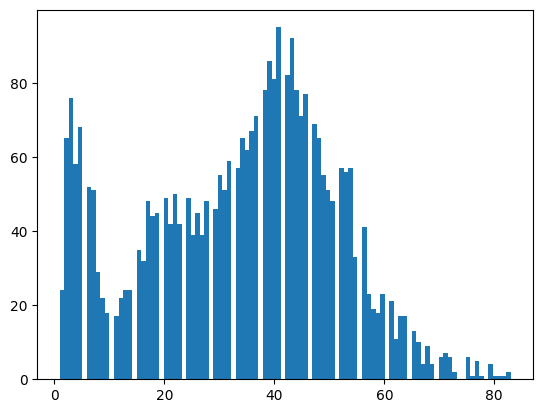

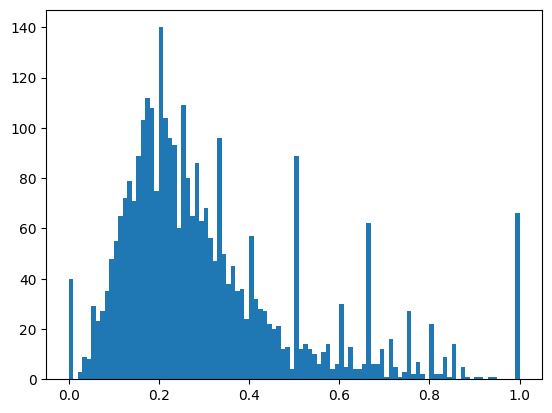

In [3]:
from matplotlib import pyplot as plt
all_generation_stats = []
for query in query_stats.values():
    for generation_stat in query:
        generation_stat["correct_percentage"] = generation_stat["generation_facts_supported"]/generation_stat["generation_facts"]
        all_generation_stats.append(generation_stat)

plt.hist([x["generation_facts"] for x in all_generation_stats], bins=100)
plt.show()
plt.hist([x["correct_percentage"] for x in all_generation_stats], bins=100)
plt.show()


In [4]:
black_box_path = os.path.join(os.getcwd(), "results", "black_box_results.jsonl")
white_box_path = os.path.join(os.getcwd(), "results", "white_box_results.jsonl")

black_box_results = []
white_box_results = []

with open(black_box_path, "r") as f:
    for line in f:
        black_box_results.append(json.loads(line))

with open(white_box_path, "r") as f:
    for line in f:
        white_box_results.append(json.loads(line))


In [6]:
aligned_white = []
aligned_black = []
for result in black_box_results:
    ids = result["sequence_ids"]
    for id in ids:
        for white_box_result in white_box_results:
            if white_box_result["sequence_id"] == id:
                aligned_white.append(white_box_result)
                aligned_black.append(result)
                break

print(len(aligned_white))
print(len(aligned_black))

3413
3413


0.593270782728055


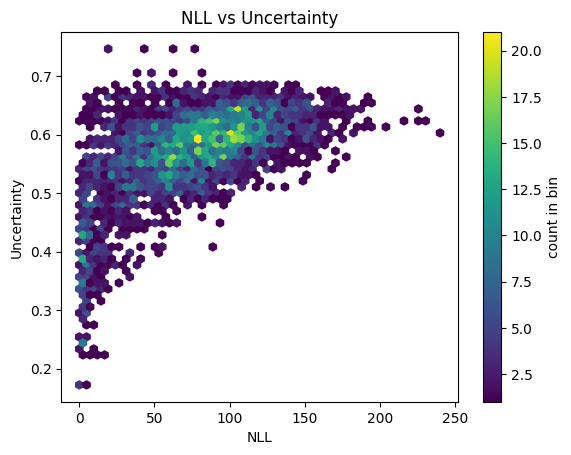

In [11]:
import numpy as np

correlation = np.corrcoef([x["nll"] for x in aligned_white], [x["uncertainty"] for x in aligned_black])[0, 1]
print(correlation)

plt.hexbin(
    [x["nll"] for x in aligned_white], 
    [x["uncertainty"] for x in aligned_black], 
    gridsize=50, 
    cmap='viridis',
    mincnt=1
)
plt.colorbar(label='count in bin')
plt.xlabel('NLL')
plt.ylabel('Uncertainty')
plt.title('NLL vs Uncertainty')
plt.show()